# Notebook 05 — Cross-Validation & Model Selection

A single train/test split is fragile: performance depends on where you drew the
boundary. **Expanding-window cross-validation** evaluates the model across multiple
consecutive windows, giving a more reliable estimate of generalisation performance
and a principled way to select hyperparameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.integrate import solve_ivp
import pyUDE as ude

np.random.seed(7)
torch.manual_seed(7)

## 1 — Generate Data: Logistic Growth

A single-state system `dx/dt = r*x*(1 - x/K)` with known analytic solution.
Simple enough that a grid search over `hidden_units` produces meaningfully different
results.

In [2]:
def logistic(t, u, r=0.5, K=10.0):
    return [r * u[0] * (1 - u[0] / K)]

sol = solve_ivp(logistic, [0, 20], [0.5], t_eval=np.linspace(0, 20, 150),
                method='RK45')
data = pd.DataFrame({'time': sol.t,
                     'x': sol.y[0] + 0.1 * np.random.randn(150)})
print(data.shape)

(150, 2)


## 2 — Visualise the Expanding Window

Each fold uses all rows up to a given time for training and the next block for
validation. The training window expands left-to-right across the time series.

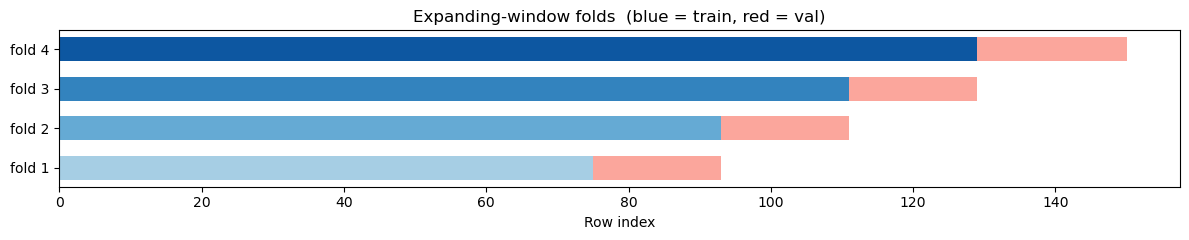

In [3]:
n = len(data)
min_train = int(0.5 * n)   # 50% minimum training size
n_splits  = 4
step      = (n - min_train) // n_splits

fig, ax = plt.subplots(figsize=(12, 2.5))
colors = plt.cm.Blues(np.linspace(0.35, 0.85, n_splits))
for fold in range(n_splits):
    train_end = min_train + fold * step
    val_end   = train_end + step if fold < n_splits - 1 else n
    ax.barh(fold, train_end,          left=0,         height=0.6,
            color=colors[fold], label=f'fold {fold+1} train')
    ax.barh(fold, val_end - train_end, left=train_end, height=0.6,
            color='salmon', alpha=0.7)

ax.set_xlabel('Row index'); ax.set_yticks(range(n_splits))
ax.set_yticklabels([f'fold {i+1}' for i in range(n_splits)])
ax.set_title('Expanding-window folds  (blue = train, red = val)')
plt.tight_layout(); plt.show()

## 3 — Basic CV Run

In [4]:
results = ude.time_series_cv(
    data,
    model_class=ude.NODE,
    model_kwargs={'hidden_units': 32, 'hidden_layers': 2},
    train_kwargs={'loss': 'derivative_matching', 'epochs': 80, 'verbose': False},
    n_splits=4,
    metric='rmse',
)

for r in results:
    print(f"fold {r['fold']}  n_train={r['n_train']:3d}  "
          f"n_val={r['n_val']}  val_score={r['val_score']:.4f}")

fold 1  n_train= 75  n_val=18  val_score=1.1099
fold 2  n_train= 93  n_val=18  val_score=0.9117
fold 3  n_train=111  n_val=18  val_score=0.6232
fold 4  n_train=129  n_val=21  val_score=1.0709


## 4 — Mean ± Std Across Folds

RMSE: mean=0.9289  std=0.1915


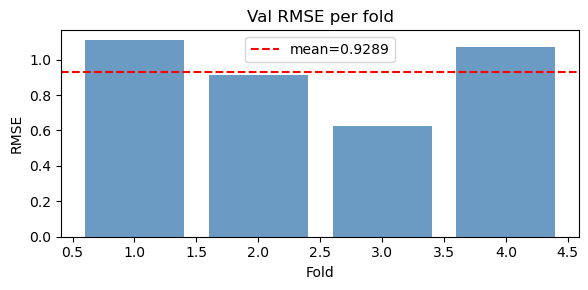

In [5]:
scores = [r['val_score'] for r in results]
print(f'RMSE: mean={np.mean(scores):.4f}  std={np.std(scores):.4f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, len(scores)+1), scores, color='steelblue', alpha=0.8)
ax.axhline(np.mean(scores), color='r', ls='--', label=f'mean={np.mean(scores):.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('RMSE'); ax.legend()
ax.set_title('Val RMSE per fold')
plt.tight_layout(); plt.show()

## 5 — Grid Search over `hidden_units`

Run CV for each configuration and record the mean val RMSE. This is the standard
way to choose network width without cheating on the test set.

In [6]:
configs = [8, 16, 32]
cv_scores = {}

for h in configs:
    res = ude.time_series_cv(
        data,
        model_class=ude.NODE,
        model_kwargs={'hidden_units': h, 'hidden_layers': 2},
        train_kwargs={'loss': 'derivative_matching', 'epochs': 50, 'verbose': False},
        n_splits=4,
        metric='rmse',
    )
    cv_scores[h] = np.mean([r['val_score'] for r in res])
    print(f'hidden_units={h:3d}  mean RMSE={cv_scores[h]:.4f}')

best_h = min(cv_scores, key=cv_scores.get)
print(f'\nBest hidden_units: {best_h}  (RMSE={cv_scores[best_h]:.4f})')

hidden_units=  8  mean RMSE=0.3522


hidden_units= 16  mean RMSE=1.0139


hidden_units= 32  mean RMSE=0.8959

Best hidden_units: 8  (RMSE=0.3522)


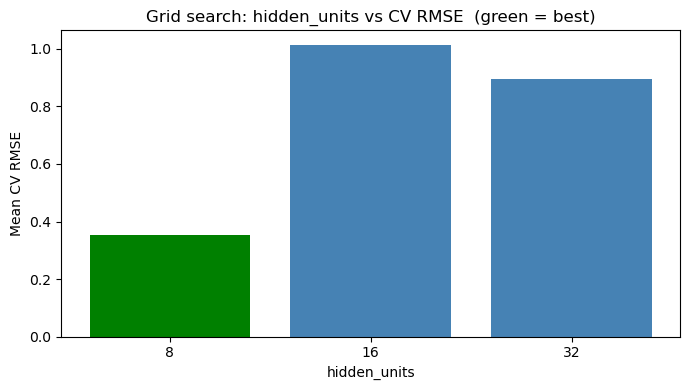

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(h) for h in configs], [cv_scores[h] for h in configs],
       color=['green' if h == best_h else 'steelblue' for h in configs])
ax.set_xlabel('hidden_units'); ax.set_ylabel('Mean CV RMSE')
ax.set_title('Grid search: hidden_units vs CV RMSE  (green = best)')
plt.tight_layout(); plt.show()

## 6 — Comparing Loss Functions

Is `derivative_matching` or `simulation` more accurate on the validation folds?

In [8]:
loss_scores = {}
for loss_fn in ['derivative_matching', 'simulation']:
    try:
        res = ude.time_series_cv(
            data,
            model_class=ude.NODE,
            model_kwargs={'hidden_units': best_h, 'hidden_layers': 2},
            train_kwargs={'loss': loss_fn, 'epochs': 50, 'verbose': False},
            n_splits=4, metric='rmse',
        )
        loss_scores[loss_fn] = np.mean([r['val_score'] for r in res])
    except ImportError:
        print(f'{loss_fn}: torchdiffeq not installed, skipping')
        continue
    print(f'{loss_fn:25s}  mean RMSE={loss_scores[loss_fn]:.4f}')

derivative_matching        mean RMSE=0.6936


simulation                 mean RMSE=0.5934


## 7 — Per-State Scores (Multi-State)

For multi-state systems (e.g. Lotka-Volterra), `state_scores` tells you which
state variable is harder to predict.

In [9]:
def lv_rhs(t, u, alpha=1.0, beta=0.1, delta=0.075, gamma=1.5):
    x, y = u
    return [alpha*x - beta*x*y, delta*x*y - gamma*y]

lv_sol = solve_ivp(lv_rhs, [0, 15], [10.0, 5.0],
                   t_eval=np.linspace(0, 15, 120), method='RK45')
lv_data = pd.DataFrame({'time': lv_sol.t,
                        'prey': lv_sol.y[0] + 0.5*np.random.randn(120),
                        'predator': lv_sol.y[1] + 0.5*np.random.randn(120)})

lv_res = ude.time_series_cv(
    lv_data,
    model_class=ude.NODE,
    model_kwargs={'hidden_units': 32, 'hidden_layers': 2},
    train_kwargs={'loss': 'derivative_matching', 'epochs': 50, 'verbose': False},
    n_splits=3, metric='rmse',
)

for r in lv_res:
    ss = r['state_scores']
    print(f"fold {r['fold']}  prey={ss['prey']:.3f}  predator={ss['predator']:.3f}  mean={r['val_score']:.3f}")

fold 1  prey=20.010  predator=11.041  mean=16.160
fold 2  prey=10.720  predator=4.772  mean=8.297
fold 3  prey=11.546  predator=13.475  mean=12.547


## 8 — Final Model: Retrain on Full Data

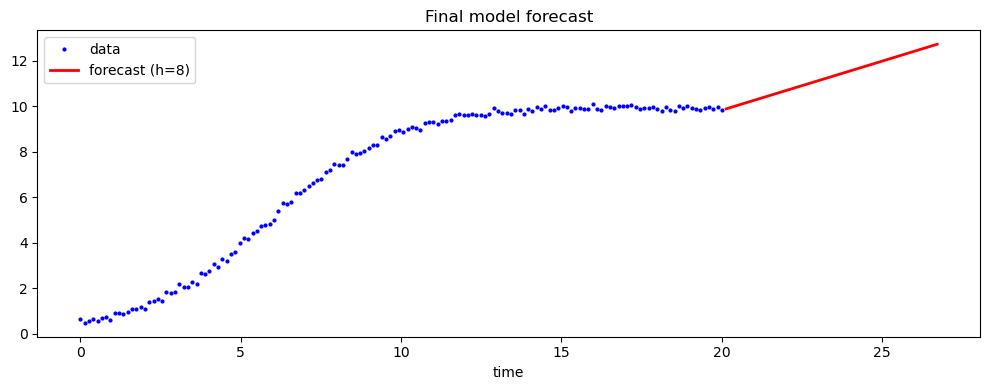

In [10]:
final_model = ude.NODE(data, hidden_units=best_h, hidden_layers=2)
final_model.train(loss='derivative_matching', epochs=100, verbose=False)

fc_final = final_model.forecast(steps=50)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(data['time'], data['x'], 'b.', ms=4, label='data')
ax.plot(fc_final['time'], fc_final['x'], 'r-', lw=2, label=f'forecast (h={best_h})')
ax.set_xlabel('time'); ax.legend(); ax.set_title('Final model forecast')
plt.tight_layout(); plt.show()

## Key Takeaways

- **Expanding-window CV** respects time order — validation is always in the future.
- **`time_series_cv`** handles the full fold loop: instantiate → train → forecast → score.
- **`state_scores`** per fold reveals which state variables are hardest to predict.
- **Grid search** over `hidden_units` with CV avoids over-fitting hyperparameters to a
  single test window.
- Retrain the final model on the **full dataset** after hyperparameter selection.